# Exercise 3 Digitization and Data Analytics - Machine Learning

## Supervised Learning - Decision Trees

Content

- Fundamental concepts in interaction with Apache Spark
- Usage of basic algorithms (Decision Trees) from the machine library MLLib within Spark

In [39]:
!pip install pyspark matplotlib seaborn

/Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1/DDA/.venv/bin/pip: line 2: /Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1 Sub/DDA/.venv/bin/python: No such file or directory
/Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1/DDA/.venv/bin/pip: line 2: exec: /Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1 Sub/DDA/.venv/bin/python: cannot execute: No such file or directory


In [40]:
%matplotlib inline
import os

# Fix Spark startup warnings about hostname and bind address by forcing
# the driver host to localhost.
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["PYSPARK_SUBMIT_ARGS"] = "--conf spark.driver.host=127.0.0.1 pyspark-shell"

# Adapt the path to point to your iris.scale and iris.csv
scaledIrisDataPath = "iris.scale"
irisDataPath = "iris.csv"

import platform
print('the python version is: ' + platform.python_version())
import pyspark
from pyspark import SparkContext

the python version is: 3.12.13


### Load the Decision Tree library:

In [41]:
# $example on$
from pyspark.ml import Pipeline
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.feature import StringIndexer, VectorIndexer, VectorAssembler
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
# $example off$
from pyspark.sql import SparkSession
from pyspark.sql.types import DoubleType, StructType, StructField, StringType

In [42]:
spark = SparkSession.builder.appName("DecisionTreeClassificationExample").getOrCreate()
# spark.sparkContext.setLogLevel("ERROR")

#### Exercise:
Load and investigate your data. What is the meaning of the values in column features? Are there any irregularities? 

In [43]:
data = spark.read.format("libsvm").load(scaledIrisDataPath)
data.show(15, False)

+-----+--------------------------------------------------------+
|label|features                                                |
+-----+--------------------------------------------------------+
|1.0  |(4,[0,1,2,3],[-0.555556,0.25,-0.864407,-0.916667])      |
|1.0  |(4,[0,1,2,3],[-0.666667,-0.166667,-0.864407,-0.916667]) |
|1.0  |(4,[0,2,3],[-0.777778,-0.898305,-0.916667])             |
|1.0  |(4,[0,1,2,3],[-0.833333,-0.0833334,-0.830508,-0.916667])|
|1.0  |(4,[0,1,2,3],[-0.611111,0.333333,-0.864407,-0.916667])  |
|1.0  |(4,[0,1,2,3],[-0.388889,0.583333,-0.762712,-0.75])      |
|1.0  |(4,[0,1,2,3],[-0.833333,0.166667,-0.864407,-0.833333])  |
|1.0  |(4,[0,1,2,3],[-0.611111,0.166667,-0.830508,-0.916667])  |
|1.0  |(4,[0,1,2,3],[-0.944444,-0.25,-0.864407,-0.916667])     |
|1.0  |(4,[0,1,2,3],[-0.666667,-0.0833334,-0.830508,-1.0])     |
|1.0  |(4,[0,1,2,3],[-0.388889,0.416667,-0.830508,-0.916667])  |
|1.0  |(4,[0,1,2,3],[-0.722222,0.166667,-0.79661,-0.916667])   |
|1.0  |(4,[0,1,2,3],[-0.7

26/06/11 12:20:12 WARN LibSVMFileFormat: 'numFeatures' option not specified, determining the number of features by going though the input. If you know the number in advance, please specify it via 'numFeatures' option to avoid the extra scan.


#### Exercise:

1. Define a transformation, that adds indices to the labels in your data (use StringIndexer), and fit it to your data.
2. Define a transformation, that adds indices to the features in your data (use VectorIndexer), and fit it to your data.
3. Split your data into training and test data.
4. Show your test data, transformed with each of the defined transformation.

#### Deal with Categorical Label and Variables

In [44]:
# Index labels, adding metadata to the label column.
# Fit on whole dataset to include all labels in index.
labelIndexer = StringIndexer(inputCol="label", outputCol="indexedLabel")
# Automatically identify categorical features, and index them.
# We specify maxCategories so features with > 4 distinct values are treated as continuous.
featureIndexer = VectorIndexer(inputCol="features", outputCol="indexedFeatures", maxCategories=4)


#### Split the data to training and test data sets

In [45]:
# Split the data into training and test sets (30% held out for testing)
(trainingData, testData) = data.randomSplit([0.7, 0.3], seed=100)


#### Show your test data in a transformed manner

In [46]:
#show indexed labels and features
labelIndexerModel = labelIndexer.fit(data)
featureIndexerModel = featureIndexer.fit(data)
trainingDataIndexed = labelIndexerModel.transform(trainingData)
trainingDataIndexed = featureIndexerModel.transform(trainingDataIndexed)
testDataIndexed = labelIndexerModel.transform(testData)
testDataIndexed = featureIndexerModel.transform(testDataIndexed)
testDataIndexed.select("label", "indexedLabel", "features", "indexedFeatures").show(15, False)


+-----+------------+------------------------------------------------------+------------------------------------------------------+
|label|indexedLabel|features                                              |indexedFeatures                                       |
+-----+------------+------------------------------------------------------+------------------------------------------------------+
|1.0  |0.0         |(4,[0,1,2,3],[-0.888889,-0.75,-0.898305,-0.833333])   |(4,[0,1,2,3],[-0.888889,-0.75,-0.898305,-0.833333])   |
|1.0  |0.0         |(4,[0,1,2,3],[-0.722222,0.166667,-0.79661,-0.916667]) |(4,[0,1,2,3],[-0.722222,0.166667,-0.79661,-0.916667]) |
|1.0  |0.0         |(4,[0,1,2,3],[-0.722222,0.166667,-0.694915,-0.916667])|(4,[0,1,2,3],[-0.722222,0.166667,-0.694915,-0.916667])|
|1.0  |0.0         |(4,[0,1,2,3],[-0.666667,-0.0833334,-0.830508,-1.0])   |(4,[0,1,2,3],[-0.666667,-0.0833334,-0.830508,-1.0])   |
|1.0  |0.0         |(4,[0,1,2,3],[-0.666667,-0.0833334,-0.830508,-1.0])   |(4,[0,1,

#### Fit Decision Tree Classification Model

Have a look at the documentation of the DecisionTreeClassifier() and its parameters 
(see https://spark.apache.org/docs/2.2.0/api/python/_modules/pyspark/ml/classification.html).

It is used to define the Decision Tree Part in the overall pipeline.

In [47]:
# Train a DecisionTree model.
dt = DecisionTreeClassifier(labelCol="indexedLabel", featuresCol="indexedFeatures")

In [48]:
help(DecisionTreeClassifier)

Help on class DecisionTreeClassifier in module pyspark.ml.classification:

class DecisionTreeClassifier(_JavaProbabilisticClassifier, _DecisionTreeClassifierParams, pyspark.ml.util.JavaMLWritable, pyspark.ml.util.JavaMLReadable)
 |  DecisionTreeClassifier(*, featuresCol: str = 'features', labelCol: str = 'label', predictionCol: str = 'prediction', probabilityCol: str = 'probability', rawPredictionCol: str = 'rawPrediction', maxDepth: int = 5, maxBins: int = 32, minInstancesPerNode: int = 1, minInfoGain: float = 0.0, maxMemoryInMB: int = 256, cacheNodeIds: bool = False, checkpointInterval: int = 10, impurity: str = 'gini', seed: Optional[int] = None, weightCol: Optional[str] = None, leafCol: str = '', minWeightFractionPerNode: float = 0.0)
 |
 |  `Decision tree <http://en.wikipedia.org/wiki/Decision_tree_learning>`_
 |  learning algorithm for classification.
 |  It supports both binary and multiclass labels, as well as both continuous and categorical
 |  features.
 |
 |  .. versionadded

#### Pipeline Architecture

Define the overall pipeline. Be aware of the necessary transformations of your data before training a model.

In [49]:
# Chain indexers and tree in a Pipeline
pipeline = Pipeline(stages=[labelIndexer, featureIndexer, dt])

# Train model.  This also runs the indexers.
model = pipeline.fit(trainingData)


#### Make predictions

In [50]:
# Make predictions.
predictions = model.transform(testData)


#### Show both, the predictions and the labels in your data.

In [51]:
# Select example rows to display.
predictions.select("prediction", "indexedLabel", "features").show(150)

+----------+------------+--------------------+
|prediction|indexedLabel|            features|
+----------+------------+--------------------+
|       1.0|         1.0|(4,[0,1,2,3],[-0....|
|       1.0|         1.0|(4,[0,1,2,3],[-0....|
|       1.0|         1.0|(4,[0,1,2,3],[-0....|
|       1.0|         1.0|(4,[0,1,2,3],[-0....|
|       1.0|         1.0|(4,[0,1,2,3],[-0....|
|       1.0|         1.0|(4,[0,1,2,3],[-0....|
|       1.0|         1.0|(4,[0,1,2,3],[-0....|
|       1.0|         1.0|(4,[0,1,2,3],[-0....|
|       1.0|         1.0|(4,[0,1,2,3],[-0....|
|       1.0|         1.0|(4,[0,1,2,3],[-0....|
|       1.0|         1.0|(4,[0,1,2,3],[-0....|
|       1.0|         1.0|(4,[0,1,2,3],[-0....|
|       1.0|         1.0|(4,[0,1,2,3],[-0....|
|       1.0|         1.0|(4,[0,1,2,3],[-0....|
|       1.0|         1.0|(4,[0,1,2,3],[-0....|
|       1.0|         1.0|(4,[0,2,3],[-0.77...|
|       0.0|         0.0|(4,[0,1,2,3],[-0....|
|       0.0|         0.0|(4,[0,1,2,3],[-0....|
|       0.0| 

In [52]:
# Count mispredicted items.
predictions.filter(predictions.prediction != predictions.label).count()

29

#### Evaluation

In [53]:
# Select (prediction, true label) and compute test error
evaluator = MulticlassClassificationEvaluator(labelCol="indexedLabel", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print("Test Error = %g " % (1.0 - accuracy),"accuracy is ", accuracy*100, "%")

Test Error = 0.0434783  accuracy is  95.65217391304348 %


#### Exercise:
Change the partition of test data, rerun and compare the test errors.

#### Print out the generated model.

In [54]:
treeModel = model.stages[2]
# summary only
print("Tree Model:")
print(treeModel)
# $example off$

Tree Model:
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_b289c893f9e5, depth=4, numNodes=11, numClasses=3, numFeatures=4


#### Visualize the Decision Tree
Use the tree text representation below to inspect splits, feature indices, and thresholds.

In [55]:
# Print the full tree structure.
print(treeModel.toDebugString)
print("\nTree depth:", treeModel.depth)
print("Number of nodes:", treeModel.numNodes)

DecisionTreeClassificationModel: uid=DecisionTreeClassifier_b289c893f9e5, depth=4, numNodes=11, numClasses=3, numFeatures=4
  If (feature 2 <= -0.5084744999999999)
   Predict: 1.0
  Else (feature 2 > -0.5084744999999999)
   If (feature 3 <= 0.375)
    If (feature 2 <= 0.33898300000000003)
     If (feature 3 <= 0.2916665)
      Predict: 0.0
     Else (feature 3 > 0.2916665)
      Predict: 2.0
    Else (feature 2 > 0.33898300000000003)
     If (feature 3 <= 0.2083335)
      Predict: 2.0
     Else (feature 3 > 0.2083335)
      Predict: 0.0
   Else (feature 3 > 0.375)
    Predict: 2.0


Tree depth: 4
Number of nodes: 11


#### Render the Decision Tree Graphically
This cell builds a simple tree layout from `toDebugString` and plots it with matplotlib.

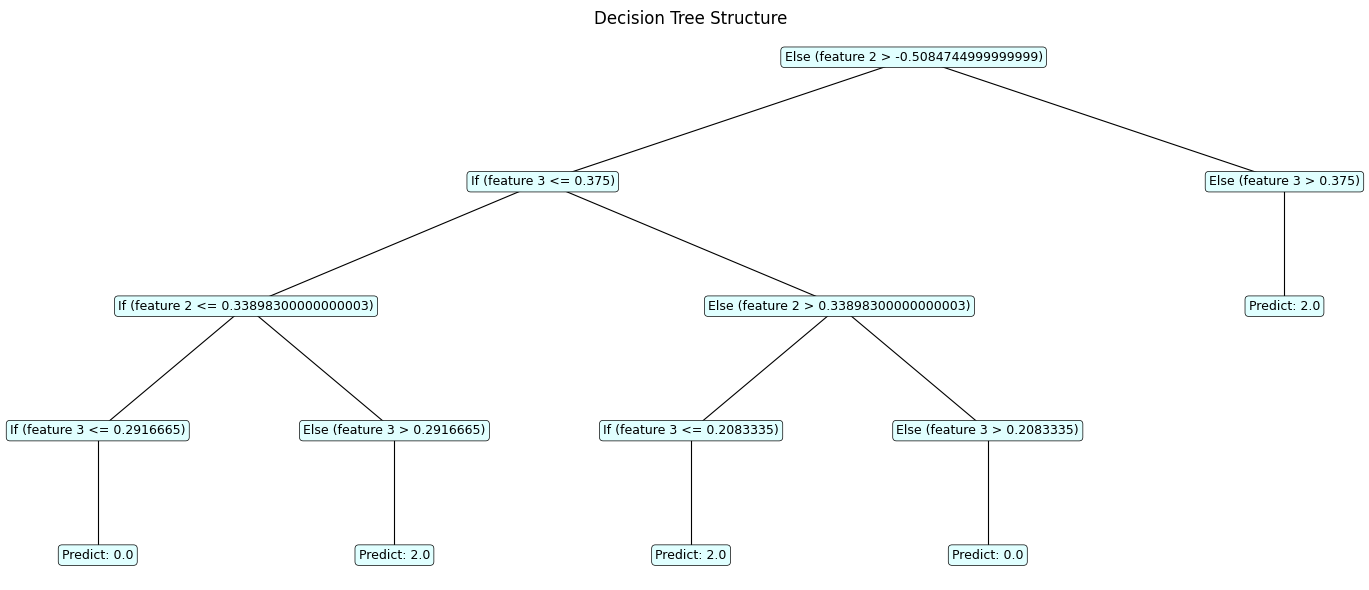

In [56]:
import matplotlib.pyplot as plt

# Parse Spark's tree text into a nested node structure.
lines = [line for line in treeModel.toDebugString.splitlines() if line.strip()]
# Skip the first header line if present.
if lines and lines[0].startswith("DecisionTree"):
    lines = lines[1:]

class Node:
    def __init__(self, text, indent):
        self.text = text
        self.indent = indent
        self.children = []

stack = []
root = None
for line in lines:
    indent = len(line) - len(line.lstrip())
    node = Node(line.strip(), indent)
    while stack and stack[-1].indent >= indent:
        stack.pop()
    if stack:
        stack[-1].children.append(node)
    else:
        root = node
    stack.append(node)

# Compute x positions for a tree layout.
positions = {}
x_counter = 0

def assign_positions(node, depth=0):
    global x_counter
    if not node.children:
        x = assign_positions.next_x
        assign_positions.next_x += 1
        positions[node] = (x, -depth)
        return x
    child_xs = [assign_positions(child, depth + 1) for child in node.children]
    x = sum(child_xs) / len(child_xs)
    positions[node] = (x, -depth)
    return x
assign_positions.next_x = 0
assign_positions(root)

# Plot the tree.
fig, ax = plt.subplots(figsize=(14, 6))
for node, (x, y) in positions.items():
    ax.text(x, y, node.text, ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='lightcyan', ec='black', lw=0.5))
    for child in node.children:
        cx, cy = positions[child]
        ax.plot([x, cx], [y, cy], 'k-', linewidth=0.8)

ax.set_axis_off()
ax.set_title('Decision Tree Structure', fontsize=12)
plt.tight_layout()
plt.show()

In [57]:
spark.stop()